In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from kmedoids import KMedoids
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px
import pickle

In [2]:
X = pd.read_csv('../../data/processed/normalized.csv')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
k3_model = KMedoids(n_clusters=3, metric='cosine', random_state=42, init='build')
k3_model.fit(X_scaled)

final_labels = k3_model.labels_
medoid_indices = k3_model.medoid_indices_
medoids = X_scaled[medoid_indices]

In [6]:
df_engineered = pd.read_csv('../../data/processed/normalized.csv')
df_meta = pd.read_csv('../../data/processed/meta.csv')
df_engineered["Cluster"] = final_labels
df_with_clusters = df_meta.join(df_engineered[["Cluster"]])

In [7]:
df_medoids = df_with_clusters.iloc[medoid_indices].copy()

In [8]:
print("\nRepresentative medoid players per cluster:")
print(df_medoids[["Name", "Club", "Nat", "Age", "CA", "PA", "Cluster"]])

print("\nCluster sizes:")
print(df_engineered["Cluster"].value_counts().sort_index())


Representative medoid players per cluster:
                     Name       Club  Nat  Age   CA   PA  Cluster
1757  Christian Frangella   Sassuolo  ITA   16   44  103        0
103        Marten de Roon   Atalanta  NED   32  146  152        1
63           Thomas Lemar  A. Madrid  FRA   27  148  165        2

Cluster sizes:
Cluster
0    652
1    593
2    576
Name: count, dtype: int64


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

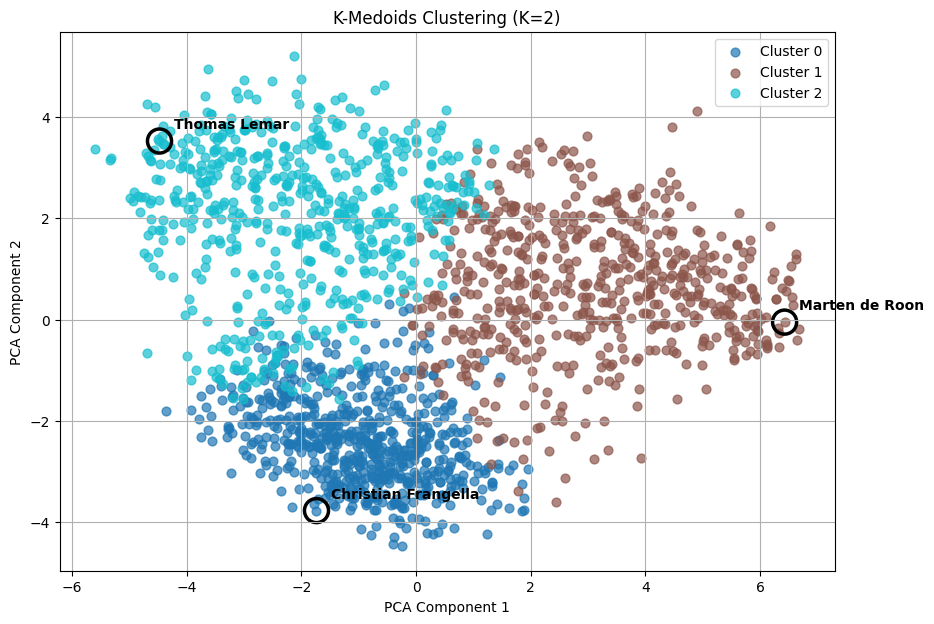

In [10]:
clusters = np.unique(final_labels)

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(clusters)))

for cluster, color in zip(clusters, colors):
    mask = (final_labels == cluster)
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        s=40, 
        c=[color], 
        label=f"Cluster {cluster}", 
        alpha=0.70
    )

for i, m in enumerate(medoid_indices):
    plt.scatter(
        X_pca[m, 0], 
        X_pca[m, 1], 
        s=300, 
        edgecolors="black",
        facecolors="none", 
        linewidths=2.5, 
        marker="o"
    )
    # Add player name next to medoid
    name = df_with_clusters.iloc[m]["Name"]
    plt.text(
        X_pca[m, 0]+0.25, 
        X_pca[m, 1]+0.25, 
        name, 
        fontsize=10, 
        fontweight="bold"
    )

plt.title(f'K-Medoids Clustering (K=2)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
df_plot = pd.DataFrame({
    "x": X_pca[:, 0],
    "y": X_pca[:, 1],
    "Cluster": final_labels,
    "Name": df_with_clusters["Name"].values,
    "Club": df_with_clusters["Club"].values,
    "CA": df_with_clusters["CA"].values,
    "PA": df_with_clusters["PA"].values,
})

df_plot["is_medoid"] = False
df_plot.loc[medoid_indices, "is_medoid"] = True

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="Cluster",
    hover_data=["Name", "Club", "CA", "PA"],
    title=f"K-Medoids Clustering (K=2) - PCA Projection",
    opacity=0.8,
)

medoids_df = df_plot[df_plot["is_medoid"]]

fig.add_scatter(
    x=medoids_df["x"],
    y=medoids_df["y"],
    mode="markers+text",
    marker=dict(
        size=18,
        symbol="circle-open",
        line=dict(width=2, color="black"),
    ),
    text=medoids_df["Name"],
    textposition="top center",
    hoverinfo="text",
    name="Medoids",
)

fig.update_layout(
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Cluster",
)

fig.show()

In [12]:
for c in df_with_clusters["Cluster"].unique():
    print(f"\n=== Cluster {c}: Top 10 by CA ===")
    display(
        df_with_clusters[df_with_clusters["Cluster"] == c]
        [["Name","Club","CA","PA"]]
        .sort_values("CA", ascending=False)
        .head(10)
    )


=== Cluster 2: Top 10 by CA ===


,Name,Club,CA,PA
0,Harry Kane,FC Bayern,184,185
1,Jude Bellingham,R. Madrid,177,188
2,Joshua Kimmich,FC Bayern,174,183
9,Martin Ødegaard,Arsenal,173,180
5,Luka Modrić,R. Madrid,171,180
7,Bruno Fernandes,Man UFC,171,174
3,Leroy Sané,FC Bayern,169,172
14,İlkay Gündoğan,Barcelona,167,167
15,Frenkie de Jong,Barcelona,165,181
10,Thiago,Liverpool,163,173



=== Cluster 1: Top 10 by CA ===


,Name,Club,CA,PA
6,Declan Rice,Arsenal,176,182
8,Eduardo Camavinga,R. Madrid,170,180
11,Federico Valverde,R. Madrid,168,175
27,Bruno Guimarães,Newcastle,165,170
31,Reece James,Chelsea,161,170
20,David Alaba,R. Madrid,159,174
16,Casemiro,Man UFC,157,170
18,Leon Goretzka,FC Bayern,157,170
24,Aurélien Tchouameni,R. Madrid,157,177
38,Sandro Tonali,Newcastle,157,171



=== Cluster 0: Top 10 by CA ===


,Name,Club,CA,PA
536,Unai Gómez,A. Bilbao,122,130
794,Luca Lipani,Sassuolo,113,169
1041,Edan Diop,AS Monaco,104,146
1193,Mattia Mannini,AS Roma,97,141
1081,Victor Eletu,AC Milan,91,146
853,Jeremy,Getafe,91,105
888,Mario Maroto,A. Madrid,90,115
812,Lewis Orford,West Ham,90,138
813,George Earthy,West Ham,90,137
918,Javier Fernández,FC Bayern,88,137


In [13]:
df_with_clusters.groupby("Cluster")["Age"].mean()

Cluster
0    16.659509
1    23.156830
2    22.243056
Name: Age, dtype: float64

In [14]:
df_with_clusters.groupby("Cluster")["PA"].median()

Cluster
0    100.0
1    138.0
2    140.0
Name: PA, dtype: float64

In [15]:
df_with_clusters.groupby("Cluster")["CA"].median()

Cluster
0     60.0
1    125.0
2    123.5
Name: CA, dtype: float64

In [16]:
df_with_clusters.groupby("Cluster")["Name"].count()

Cluster
0    652
1    593
2    576
Name: Name, dtype: int64

In [17]:
cols = X.columns.tolist()
df_engineered.groupby("Cluster")[cols].mean()

,Acc,Agi,Bal,Jum,Nat.1,Pac,Sta,Str,Agg,Ant,...,Fir,Fre,Hea,Lon,L Th,Mar,Pas,Pen,Tck,Tec
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.148618,0.950201,-0.395963,-0.134171,1.314091,1.003408,-0.024933,-0.897102,0.674124,-0.352218,...,1.177281,-0.692954,-0.715867,0.009004,-1.390636,-0.345236,0.939121,-1.352723,0.367705,0.861674
1,0.216619,0.135596,0.429750,-0.080402,0.852421,0.298349,0.694024,0.124175,0.720299,0.379967,...,0.314857,-1.245515,-0.318634,-0.550190,-1.602938,-0.104964,0.494982,-1.148060,0.526996,0.273131
2,0.534772,0.607744,0.085676,-0.904495,0.552290,0.464644,0.340571,-0.699330,-0.102710,0.077665,...,0.850557,-0.065594,-1.287432,0.032716,-2.034257,-1.261190,0.808041,-0.292394,-0.728423,0.958194


In [18]:
cluster_means_k2 = df_engineered.groupby("Cluster")[cols].mean()
feature_diff = cluster_means_k2.max(axis=0) - cluster_means_k2.min(axis=0)
top10_diff = feature_diff.sort_values(ascending=False).head(10)

print(top10_diff)

Cor    1.380148
Fla    1.306598
Tck    1.255419
Dri    1.208970
Fre    1.179920
Mar    1.156226
Bra    1.072620
Pen    1.060329
Tea    1.044910
Pos    1.033940
dtype: float64
